In [22]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', as_frame=False)
print(type(mnist))

<class 'sklearn.utils._bunch.Bunch'>


In [23]:
X,y = mnist.data , mnist.target
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(70000, 784))

In [24]:
y

array(['5', '0', '4', ..., '4', '5', '6'], shape=(70000,), dtype=object)

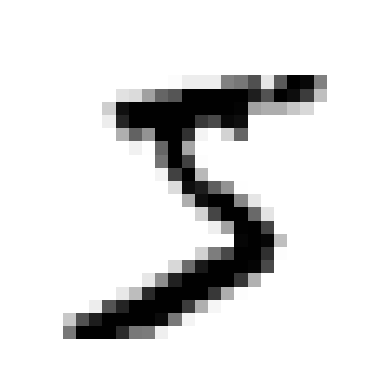

5


In [25]:
import matplotlib.pyplot as plt

def plot_digit(image_data):
    image = image_data.reshape(28,28)
    plt.imshow(image,cmap="binary")
    plt.axis("off")

some_digit = X[0]
plot_digit(some_digit)
plt.show()

print(y[0])


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier

In [27]:
X_train, X_test, y_train, y_test = X[:60000],X[60000:],y[:60000],y[60000:]
y_train_5 = (y_train == "5")
y_test = (y_train == "5")


In [28]:
sgd_clf = SGDClassifier()
sgd_clf.fit(X_train,y_train_5)

print(sgd_clf.predict([some_digit]))

[ True]


In [29]:
from sklearn.model_selection import cross_val_score
score = cross_val_score(sgd_clf,X_train,y_train_5,cv=3,scoring="accuracy")
print(score)

In [31]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")
score = cross_val_score(dummy,X_train,y_train_5,cv=3,scoring="accuracy")
print(score)

[0.90965 0.90965 0.90965]


In [33]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix

y_train_pred = cross_val_predict(sgd_clf,X_train,y_train_5,cv=3)
conf_matrix = confusion_matrix(y_train_5,y_train_pred)
conf_matrix

array([[54196,   383],
       [ 1898,  3523]])

In [37]:
from sklearn.metrics import precision_score,recall_score,f1_score
precision_score(y_train_5,y_train_pred)

0.9019457245263697

In [38]:
recall_score(y_train_5,y_train_pred)

0.6498800959232613

In [39]:
f1_score(y_train_5,y_train_pred)

0.7554411922375898